### Support Vector Machines (SVMs) with Kernel Functions

Accuracy: 0.80


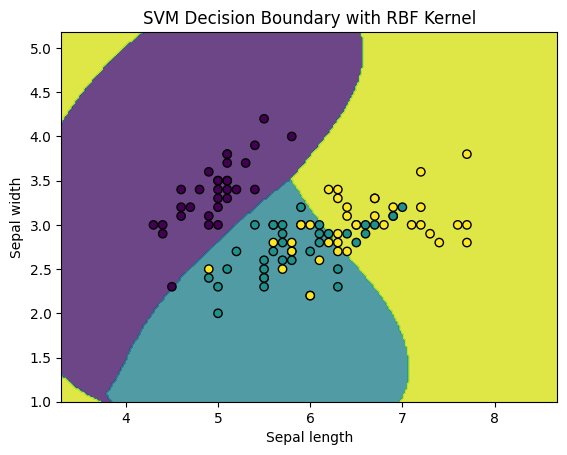

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data[:, :2]  # We'll use only the first two features for visualization
y = iris.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create an SVM classifier with an RBF kernel
svm = SVC(kernel='rbf', gamma=0.7, C=1.0)

# Train the SVM
svm.fit(X_train, y_train)

# Make predictions
y_pred = svm.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Plot the decision boundary
def plot_decision_boundary(X, y, model):
    h = .02  # Step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.title('SVM Decision Boundary with RBF Kernel')
    plt.show()

plot_decision_boundary(X_train, y_train, svm)

### Here’s what’s going on in the above code:

- Kernel Selection: We use the RBF kernel (kernel=’rbf’) to handle non-linear data
- Gamma Parameter: The gamma parameter controls the influence of each training example, where a higher gamma value results in a more complex decision boundary
- C Parameter: The C parameter controls the trade-off between achieving a low training error and a low testing error

### Kernel Principal Component Analysis (Kernel PCA)

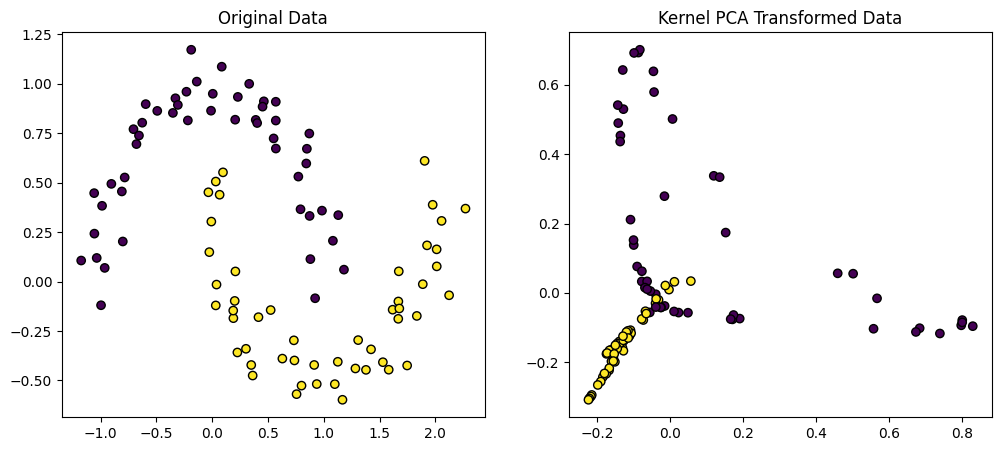

In [3]:
from sklearn.decomposition import KernelPCA
from sklearn.datasets import make_moons

# Generate a non-linear dataset
X, y = make_moons(n_samples=100, noise=0.1, random_state=42)

# Apply Kernel PCA with an RBF kernel
kpca = KernelPCA(kernel='rbf', gamma=15, n_components=2)
X_kpca = kpca.fit_transform(X)

# Plot the original data and the transformed data
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
plt.title('Original Data')

plt.subplot(1, 2, 2)
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y, edgecolors='k', marker='o')
plt.title('Kernel PCA Transformed Data')

plt.show()

### Here’s an explanation of the code above:

- Kernel Selection: We use the RBF kernel (kernel=’rbf’) to capture non-linear relationships in the data
- Gamma Parameter: The gamma parameter controls the influence of each data point, where a higher gamma value results in a more complex transformation
- Number of Components: We reduce the data to 2 dimensions (n_components=2) for visualization

### Implementing the Kernel Trick from Scratch

#### Step 1: Define the RBF Kernel Function

In [6]:
import numpy as np

def rbf_kernel(x1, x2, gamma=1.0):
    """
    Compute the RBF kernel between two vectors x1 and x2.
    
    Parameters:
    - x1, x2: Input vectors.
    - gamma: Kernel parameter.
    
    Returns:
    - Kernel value (scalar).
    """
    squared_distance = np.sum((x1 - x2) ** 2)
    return np.exp(-gamma * squared_distance)

#### Step 2: Compute the Kernel Matrix

In [7]:
def compute_kernel_matrix(X, kernel_function, gamma=1.0):
    """
    Compute the kernel matrix for a dataset X using a given kernel function.
    
    Parameters:
    - X: Input dataset (n_samples, n_features).
    - kernel_function: Kernel function to use.
    - gamma: Kernel parameter.
    
    Returns:
    - Kernel matrix (n_samples, n_samples).
    """
    n_samples = X.shape[0]
    kernel_matrix = np.zeros((n_samples, n_samples))
    
    for i in range(n_samples):
        for j in range(n_samples):
            kernel_matrix[i, j] = kernel_function(X[i], X[j], gamma)
    
    return kernel_matrix

#### Step 3: Apply the Kernel Trick to a Simple Dataset

In [8]:
# Generate a simple 2D dataset
X = np.array([[1, 2], [2, 3], [3, 4], [4, 5]])

# Compute the kernel matrix using the RBF kernel
gamma = 0.1
kernel_matrix = compute_kernel_matrix(X, rbf_kernel, gamma)

print("Kernel Matrix (RBF Kernel):")
print(kernel_matrix)

Kernel Matrix (RBF Kernel):
[[1.         0.81873075 0.44932896 0.16529889]
 [0.81873075 1.         0.81873075 0.44932896]
 [0.44932896 0.81873075 1.         0.81873075]
 [0.16529889 0.44932896 0.81873075 1.        ]]
